# Exercise 1: Linear Regression — California Housing

This dataset comes from the 1990 U.S. Census and is built directly into
scikit-learn — no download needed. 

Each row represents a census block
group in California, with features describing the area's demographics
and housing stock:

- **MedInc** — median income in the block group (in tens of thousands of USD)
- **HouseAge** — median house age
- **AveRooms** / **AveBedrms** — average rooms / bedrooms per household
- **Population** — block group population
- **AveOccup** — average household occupancy
- **Latitude** / **Longitude** — location

**Target (what we're predicting): MedHouseVal** — median house value
for the block group, in hundreds of thousands of USD.

## 1. load and print the dataset

In [28]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

# fetch_california_housing() returns a scikit-learn "Bunch" object —
# essentially a dictionary that also supports attribute-style access
# (bunch.data works the same as bunch['data']).
#
# Its main pieces:
#   .data          -> NumPy array of the 8 feature columns (shape: n_samples x 8)
#   .target        -> NumPy array of the target values (median house value)
#   .feature_names -> list of the 8 feature column names, e.g. ['MedInc', 'HouseAge', ...]
#   .target_names  -> name of the target column
#   .frame         -> a single combined pandas DataFrame with features + target together
#                     (only populated when as_frame=True, which is what we're using here)
#   .DESCR         -> a long text description: dataset origin, units, and known caveats
housing = fetch_california_housing(as_frame=True)
print(housing.keys())

df = housing.frame
print(df.head())
df.head()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88    -122.23        4.526
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86    -122.22        3.585
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85    -122.24        3.521
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85    -122.25        3.413
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85    -122.25        3.422


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. check correlation heatmap

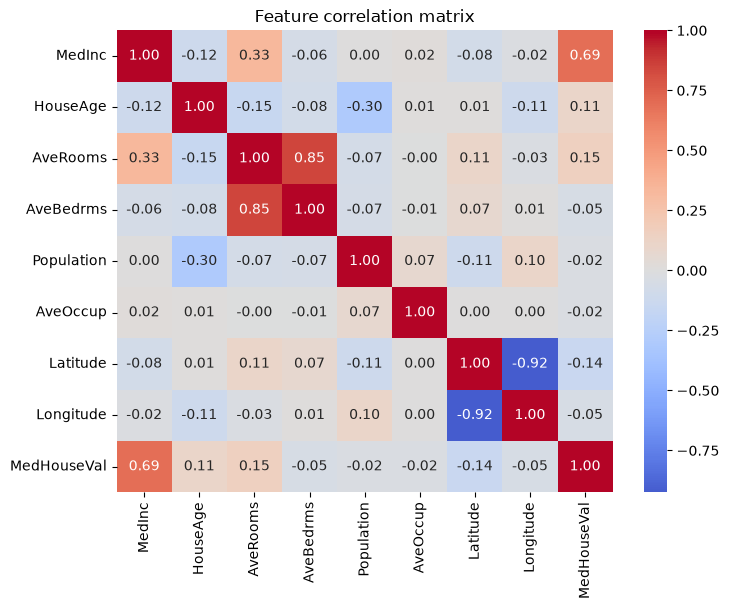

In [29]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.show()

## 3. feature engineer the highly correlated variables

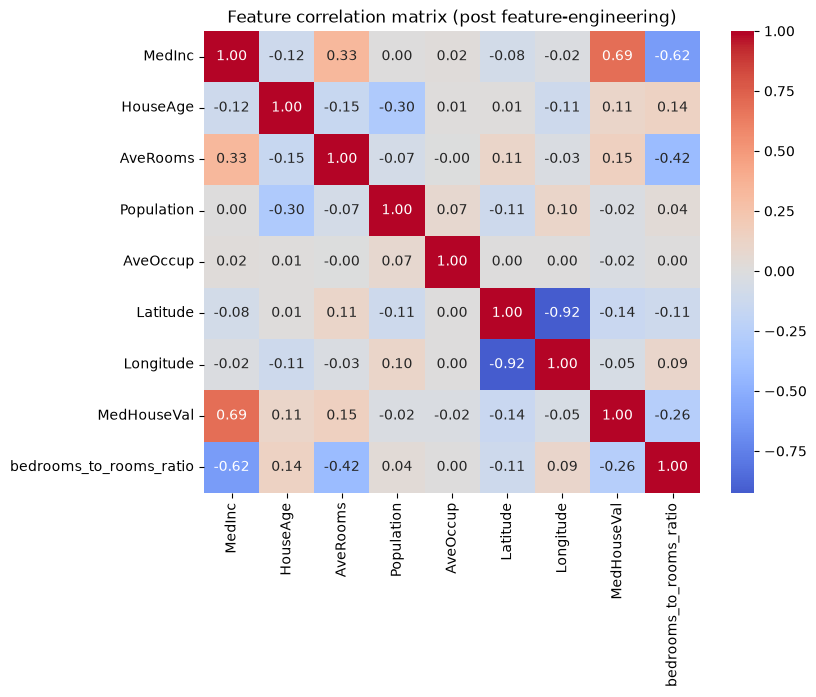

In [30]:
# --- Feature engineering (using RAW values) ---

# AveRooms and AveBedrms were 0.85 correlated — classic redundancy.
# Replace them with a ratio that captures the useful signal without the overlap.
df["bedrooms_to_rooms_ratio"] = df["AveBedrms"] / df["AveRooms"]
df = df.drop(columns=["AveBedrms"])

# Latitude / Longitude: left untouched for now. They're not a redundancy problem
# (their -0.92 correlation is with each other, not something to fix by dropping
# one — both are needed to locate a point), so no engineering decision made here yet.
# Revisiting this (e.g. distance-to-city-center) is a candidate for later, after we
# have a baseline model to compare against.

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix (post feature-engineering)")
plt.show()

## 4. look for skewness in distribution

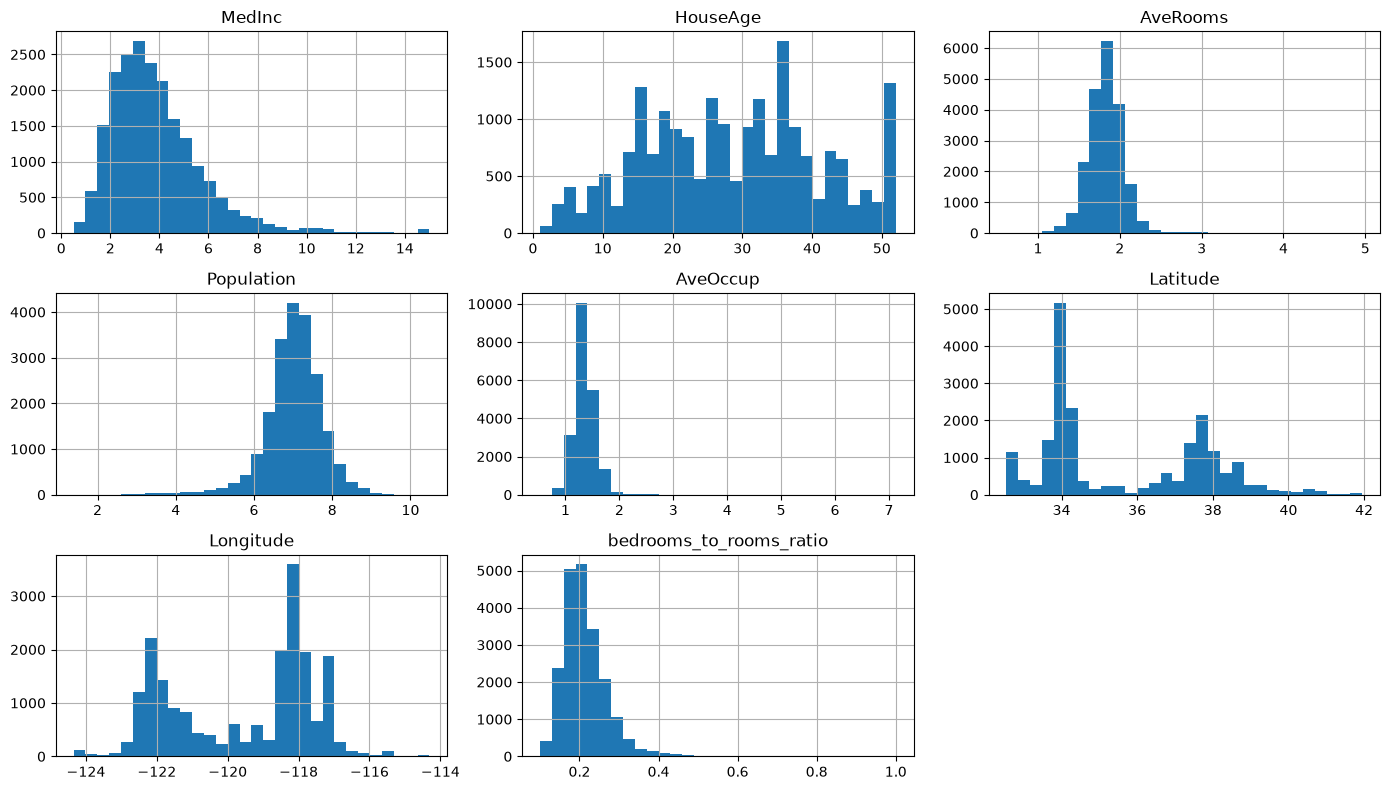

In [33]:
import numpy as np

# distributions of the current feature set (post feature-engineering),
# excluding the target column
feature_cols = df.columns.drop("MedHouseVal")
df[feature_cols].hist(figsize=(14, 8), bins=30)
plt.tight_layout()
plt.show()

## 5. log-transform relevant variables

            raw_corr  log_corr
AveRooms    0.238738  0.237188
Population -0.016118 -0.015773
AveOccup   -0.267497 -0.267836


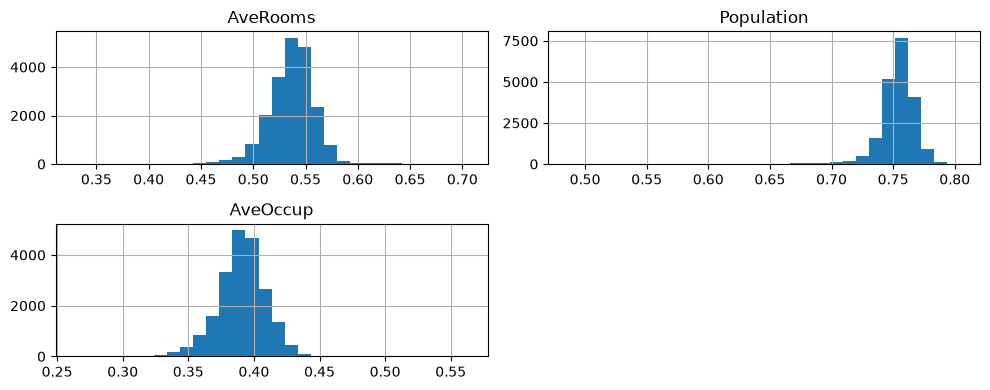

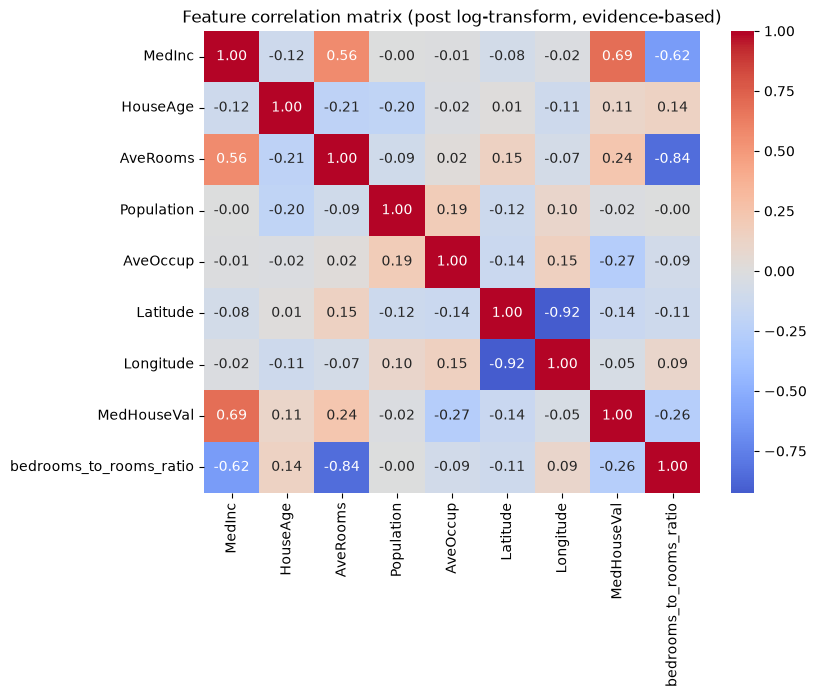

In [37]:
skewed = ["AveRooms", "Population", "AveOccup"]

# create log versions alongside the originals — don't replace yet
for col in skewed:
    df[f"log_{col}"] = np.log1p(df[col])

# compare each raw feature's correlation with the target against its log version
comparison = pd.DataFrame({
    "raw_corr": df[skewed].corrwith(df["MedHouseVal"]),
    "log_corr": df[[f"log_{c}" for c in skewed]].corrwith(df["MedHouseVal"]).set_axis(skewed)
})
print(comparison)

# keep the log version only where it's a clear improvement over raw
for col in skewed:
    if abs(comparison.loc[col, "log_corr"]) > abs(comparison.loc[col, "raw_corr"]):
        df[col] = df[f"log_{col}"]

# clean up the temporary log_ columns either way
df = df.drop(columns=[f"log_{c}" for c in skewed])

df[skewed].hist(figsize=(10, 4), bins=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix (post log-transform, evidence-based)")
plt.show()

## 2. check correlation heatmap

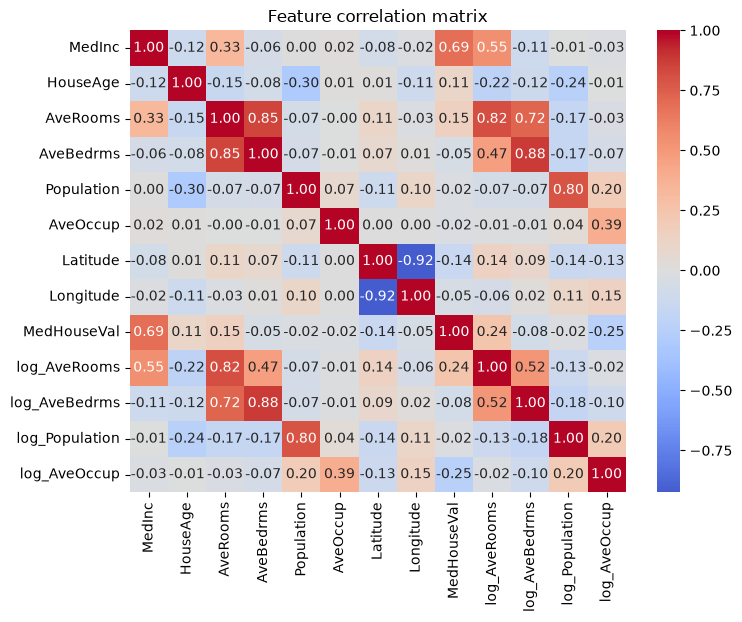

In [18]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.show()

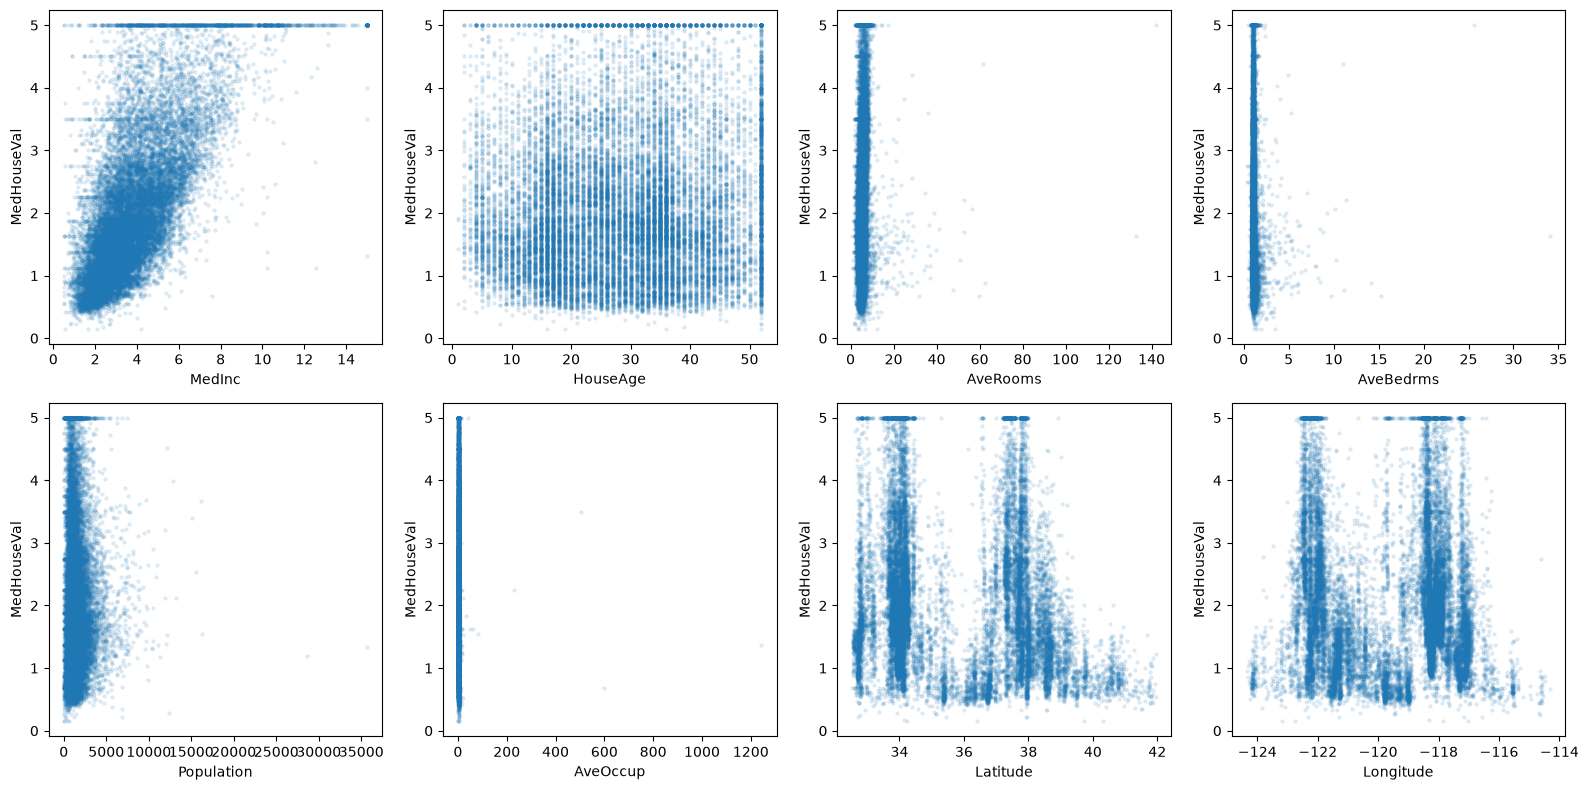

In [17]:
import matplotlib.pyplot as plt

# Scatter each feature against the target, in a grid, to visually check
# whether the relationship looks linear (good for linear regression)
# or curved/non-linear (a sign linear regression alone may struggle).
features = housing.feature_names
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, feature in zip(axes.flatten(), features):
    ax.scatter(df[feature], df["MedHouseVal"], alpha=0.1, s=5)
    ax.set_xlabel(feature)
    ax.set_ylabel("MedHouseVal")

plt.tight_layout()
plt.show()